In [1]:
import pandas as pd
import numpy as np
from models.fista_lr import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from data.loader import load_openml_data, preprocess_data
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar

In [2]:
# Process all datasets
np.random.seed(42)

datasets_config = {
    "Spambase (OpenML - 44)": {"source": "openml", "id": 44},
    "Musk V2 (OpenML - 46615)": {"source": "openml", "id": 46615},
    # "Gisette (UCI - 170)": {"source": "uci", "id": 170},
    # "Polish Companies Bankruptcy (UCI - 365)": {"source": "uci", "id": 365}
}

processed_datasets = {}

for name, config in datasets_config.items():
    print(f"\nProcessing: {name}")

    # Load
    if config["source"] == "openml":
        X_raw, y_raw = load_openml_data(config["id"])
    elif config["source"] == "uci":
        X_raw, y_raw = load_uci_data(config["id"], config.get("binarize", False))

    # Preprocess
    X_clean = preprocess_data(X_raw)
    print(f"Features after preprocessing: {X_clean.shape[1]}")

    # Generate missing mechanisms
    y_mcar = generate_mcar(X_clean, y_raw, c=0.3)
    y_mar1 = generate_mar1(X_clean, y_raw)
    y_mar2 = generate_mar2(X_clean, y_raw)
    y_mnar = generate_mnar(X_clean, y_raw)

    # Statistics
    print("% of missing data:")
    print(f" - MCAR: {(y_mcar == -1).mean():.2%}")
    print(f" - MAR1: {(y_mar1 == -1).mean():.2%}")
    print(f" - MAR2: {(y_mar2 == -1).mean():.2%}")
    print(f" - MNAR: {(y_mnar == -1).mean():.2%}")

    # For task 2 and 3 (idk how you want it to be saved)
    processed_datasets[name] = {
        "X": X_clean,
        "y_true": y_raw,
        "y_mcar": y_mcar,
        "y_mar1": y_mar1,
        "y_mar2": y_mar2,
        "y_mnar": y_mnar
    }


Processing: Spambase (OpenML - 44)
Features after preprocessing: 56
% of missing data:
 - MCAR: 29.10%
 - MAR1: 47.27%
 - MAR2: 38.95%
 - MNAR: 85.29%

Processing: Musk V2 (OpenML - 46615)
Features after preprocessing: 107
% of missing data:
 - MCAR: 30.34%
 - MAR1: 48.18%
 - MAR2: 40.03%
 - MNAR: 82.07%


In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, random_state=1)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=1)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [3]:
lr = LogisticRegression(lmbd = 2, max_iter = 1500, tol = 1e-4)
lr.fit(X_train, y_train)
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Balanced accuracy for test set and lambda = 2: {ba}")

Balanced accuracy for test set and lambda = 2: 0.9643382352941177


/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 2, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(


In [4]:
lr_best = lr.validate(X_valid, y_valid, measure="bal_acc")
pred = lr_best.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Best lambda based on balanced accuracy on validation set: {lr_best.lmbd}")
print(f"Balanced accuracy on test set for optimized lambda: {ba}")

/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.001, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.005, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.01, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.05, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.1, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.3, max_iter = 15

Best lambda based on balanced accuracy on validation set: 0.001
Balanced accuracy on test set for optimized lambda: 0.9727941176470588


/Users/ola/projects/aml-project-1/src/models/fista_lr.py:193: RuntimeWarning: For lambda = 0.001, max_iter = 1500 and tol = 0.0001 the algorithm did not converge
  warnings.warn(


In [5]:
lr_best.beta

0      3.940801
1     -0.311398
2      5.502333
3      2.143039
4      3.405169
5     12.905840
6     -4.211687
7    -24.878977
8      0.773699
9      7.401320
10   -17.448398
11    -3.485550
12    -0.826486
13    -5.258813
14     9.799469
15     9.667541
16     1.373345
17   -13.860550
18    -4.582673
19    18.157308
20    -9.911972
21    -6.192358
22    -8.812145
23    -6.652778
24    -7.856927
25    -9.437426
26    -5.614420
27     7.388737
28    -2.242830
29   -13.714768
dtype: float64

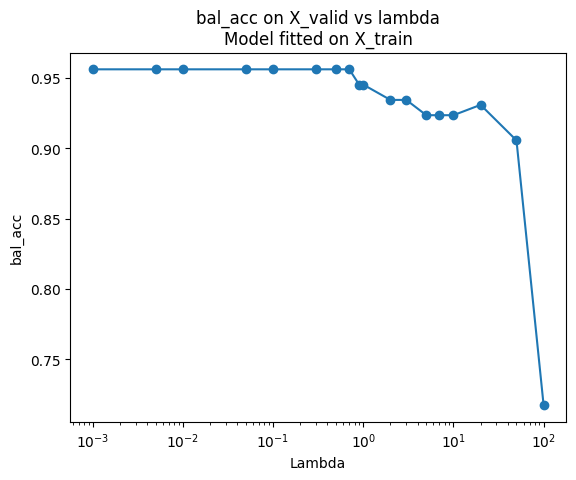

In [6]:
lr.plot("bal_acc")

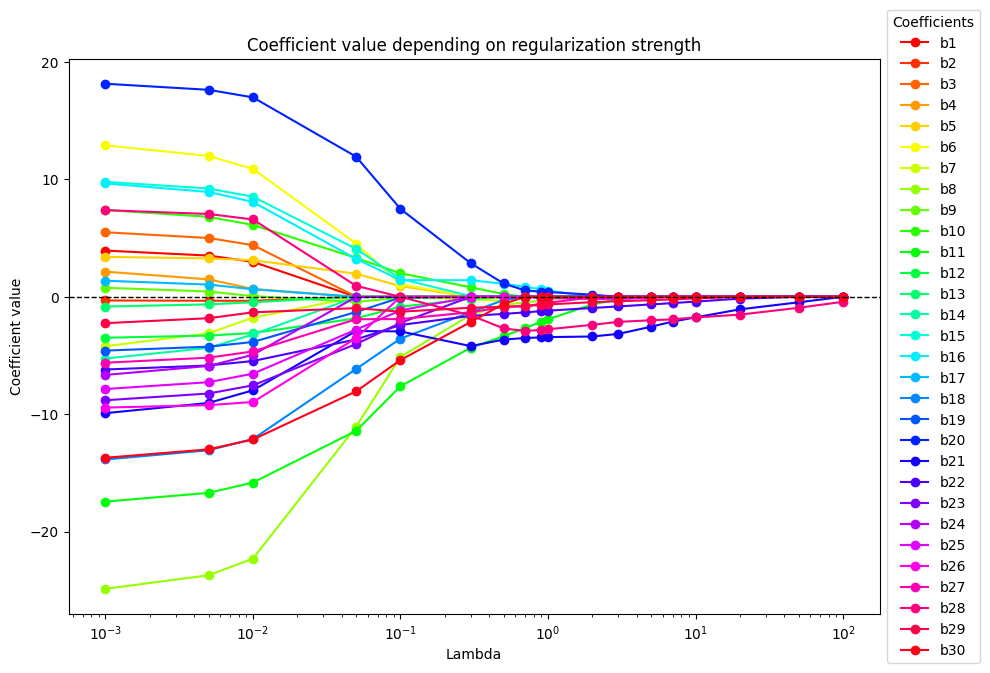

In [7]:
lr.plot_coefficients()